# Differentiation

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')


def parse_params(folder_name):
    """
    Example:
    n_10_rq_1_v0_1 -> {"n": 10, "rq": 1, "v0": 1}
    """
    parts = folder_name.split("_")
    params = {}

    for i in range(0, len(parts) - 1, 2):
        key = parts[i]
        val = parts[i + 1]

        try:
            params[key] = float(val)
        except ValueError:
            params[key] = val
            pass

    return params


def analyze_h5(h5_path, t=-1):
    with h5py.File(h5_path, "r") as f:
        psi = f["solution/psi_hist"][t]
        qx = f["solution/qx_hist"][t]
        qy = f["solution/qy_hist"][t]
        Nb = f["grid"].attrs["Nbd"]

    qmag = np.sqrt(qx**2 + qy**2)

    area_psi = np.mean(0.5 * (np.clip(psi, -1, 1) + 1))
    area_q = np.mean(qmag)

    return {
        "area_psi": area_psi,
        "area_q": area_q,
        "max_psi": np.max(psi),
        "has_diff": np.any(psi > 0.9),
        "Nb": Nb,
    }


def scan(base_dir):
    rows = []

    for param_folder in sorted(os.listdir(base_dir)):
        param_dir = os.path.join(base_dir, param_folder)

        if not os.path.isdir(param_dir):
            continue

        params = parse_params(param_folder)

        for sim_folder in sorted(os.listdir(param_dir)):
            sim_dir = os.path.join(param_dir, sim_folder)

            if not os.path.isdir(sim_dir):
                continue

            h5_files = [f for f in os.listdir(sim_dir) if f.endswith(".h5")]
            if not h5_files:
                continue

            h5_path = os.path.join(sim_dir, h5_files[0])
            obs = analyze_h5(h5_path)

            row = {
                "param_folder": param_folder,
                "sim_folder": sim_folder,
                "h5_path": h5_path,
            }

            row.update(params)
            row.update(obs)
            rows.append(row)

    return pd.DataFrame(rows)


def plot_area_vs_nb(df, rq, v0, y="area_psi"):
    # Filter dataset
    df_sub = df[(df["rq"] == rq) & (df["v0"] == v0)]

    if df_sub.empty:
        raise ValueError("No data for given rq and v0")

    # Group by number of beads
    grouped = df_sub.groupby("nb")[y].mean()

    # fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(
        grouped.index,
        grouped.values,
        "o-", 
        label=f"rq={rq}, v0={v0}"
    )

    # return fig, ax



def plot_vs(df, xparam, y="area_psi"):
    grouped = df.groupby(xparam)[y]

    mean = grouped.mean()
    std = grouped.std()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.errorbar(
        mean.index,
        mean.values,
        yerr=std.values,
        fmt="o-",
        capsize=3,
    )

    ax.set_xlabel(xparam)
    ax.set_ylabel(y)
    ax.grid()
    ax.set_ylim(-0.1, 1.1)

    return fig, ax


def print_available_parameters(df):
    """
    Print unique values available for each parameter column.
    """

    # Columns you want to ignore
    ignore = {
        "param_folder",
        "sim_folder",
        "h5_path",
        "area_psi",
        "area_q",
        "max_psi",
        "has_diff",
        "diff",
    }

    # Candidate parameter columns
    param_cols = [c for c in df.columns if c not in ignore]

    print("=" * 50)

    for col in sorted(param_cols):

        # Remove NaNs and sort values
        vals = sorted(df[col].dropna().unique())

        print(f"{col}:")
        print(vals)
        print()

    print("=" * 50)



def plot_binary_phase_scatter(df, x, y, fixed=None, ax=None):
    """
    Binary phase diagram using scatter points.

    diff = True  -> differentiated
    diff = False -> not differentiated
    """

    d = df.copy()

    # Apply fixed parameter filters
    if fixed is not None:
        for k, v in fixed.items():
            d = d[d[k] == v]

    if d.empty:
        raise ValueError("No data after filtering")

    # Separate differentiated / non differentiated
    d_true = d[d["has_diff"] == True]
    d_false = d[d["has_diff"] == False]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    # Differentiated
    from matplotlib.colors import LogNorm

    cvals = d_true["area_psi"].values

    # avoid non-positive values for log scale by finding smallest positive value
    positive = cvals[cvals > 0]
    if positive.size > 0:
        vmin = positive.min()
    else:
        vmin = 1e-6

    vmax = max(cvals.max(), vmin)
    norm = LogNorm(vmin=vmin, vmax=vmax)

    cm = ax.scatter(
        d_true[x],
        d_true[y],
        marker="o",
        s=80,
        label="Differentiated",
        c=cvals,
        cmap="viridis",
        norm=norm,
    )
    cbar = fig.colorbar(cm, ax=ax)
    cbar.set_label("Area of psi (log scale)")

    # Non differentiated
    ax.scatter(
        d_false[x],
        d_false[y],
        marker="x",
        s=80,
        label="No differentiation"
    )



    ax.set_xlabel(x)
    ax.set_ylabel(y)

    if fixed is not None:
        title = ", ".join([f"{k}={v}" for k, v in fixed.items()])
        ax.set_title(title)

    ax.grid()
    # ax.legend()

    return fig, ax


# Beads no dynamics

In [12]:
from scipy.integrate import quad

base_dir = "outputs/differentiation_sweep/"

df = scan(base_dir)

display(df)

print_available_parameters(df)

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,param_folder,sim_folder,h5_path,dist,sig,rbm,x0,dpsi,area_psi,area_q,max_psi,has_diff,Nb
0,dist_pol_sig_0.5_rbm_0.1_x0_25.0_dpsi_1.0,sim_data_20260601_164419,outputs/differentiation_sweep/dist_pol_sig_0.5...,pol,0.5,0.1,25.0,1.00,2.932343e-15,0.0,-1.0,False,0.157080
1,dist_pol_sig_0.5_rbm_0.2_x0_25.0_dpsi_1.0,sim_data_20260601_164419,outputs/differentiation_sweep/dist_pol_sig_0.5...,pol,0.5,0.2,25.0,1.00,3.084326e-15,0.0,-1.0,False,0.314159
2,dist_pol_sig_0.5_rbm_0.3_x0_25.0_dpsi_1.0,sim_data_20260601_164419,outputs/differentiation_sweep/dist_pol_sig_0.5...,pol,0.5,0.3,25.0,1.00,3.175056e-15,0.0,-1.0,False,0.471239
3,dist_pol_sig_0.5_rbm_0.5_x0_25.0_dpsi_1.0,sim_data_20260601_164419,outputs/differentiation_sweep/dist_pol_sig_0.5...,pol,0.5,0.5,25.0,1.00,3.295904e-15,0.0,-1.0,False,0.785398
4,dist_pol_sig_0.5_rbm_0.7_x0_25.0_dpsi_1.0,sim_data_20260601_164419,outputs/differentiation_sweep/dist_pol_sig_0.5...,pol,0.5,0.7,25.0,1.00,3.377594e-15,0.0,-1.0,False,1.099557
...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,dist_pol_sig_5_rbm_1.0_x0_25.0_dpsi_0.01,sim_data_20260521_120737,outputs/differentiation_sweep/dist_pol_sig_5_r...,pol,5.0,1.0,25.0,0.01,1.546295e-01,0.0,1.0,True,157.079450
509,dist_pol_sig_5_rbm_1.0_x0_25.0_dpsi_0.5,sim_data_20260521_120737,outputs/differentiation_sweep/dist_pol_sig_5_r...,pol,5.0,1.0,25.0,0.50,1.546295e-01,0.0,1.0,True,157.079450
510,dist_pol_sig_5_rbm_1.0_x0_25.0_dpsi_1.0,sim_data_20260521_120737,outputs/differentiation_sweep/dist_pol_sig_5_r...,pol,5.0,1.0,25.0,1.00,1.546295e-01,0.0,1.0,True,157.079450
511,dist_pol_sig_5_rbm_1.0_x0_25.0_dpsi_2.0,sim_data_20260521_120737,outputs/differentiation_sweep/dist_pol_sig_5_r...,pol,5.0,1.0,25.0,2.00,1.546295e-01,0.0,1.0,True,157.079450


Nb:
[np.float64(0.15707963267948966), np.float64(0.3141592653589793), np.float64(0.47123889803846897), np.float64(0.6283185307179586), np.float64(0.7853981633974484), np.float64(1.0995574287564274), np.float64(1.2566370614359172), np.float64(1.4137166941154071), np.float64(1.5707963267948968), np.float64(1.8849555921538756), np.float64(3.1415926535897936), np.float64(3.9269908169872414), np.float64(4.39822971502571), np.float64(5.654866776461629), np.float64(6.283185307179587), np.float64(7.853981633974483), np.float64(10.053096483169178), np.float64(11.780972450961723), np.float64(12.72344953933295), np.float64(13.879553437402164), np.float64(15.620818240889314), np.float64(15.707945020072694), np.float64(19.63495408493621), np.float64(20.106192966338355), np.float64(25.4468990786659), np.float64(27.48893571891069), np.float64(27.759106874804328), np.float64(30.159289449507533), np.float64(31.241636481778627), np.float64(31.41589004014539), np.float64(35.34291735288518), np.float64(38

(0.0, 30.05)

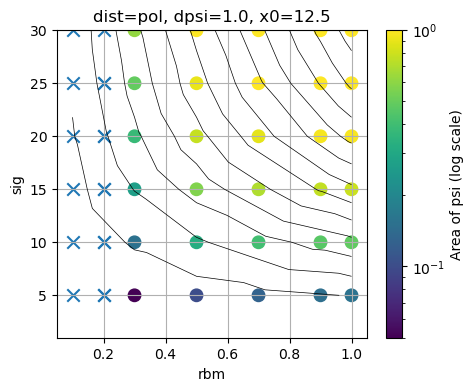

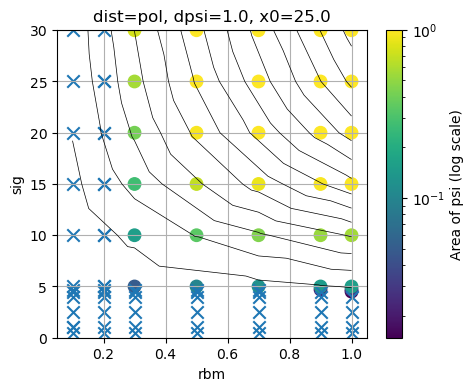

In [15]:
fixed = {
        "dist": "pol",
        "dpsi": 1.0,
        "x0": 12.5
        }

fig, ax = plt.subplots(figsize=(5, 4))
plot_binary_phase_scatter(
    df,
    x="rbm",
    y="sig",
    fixed=fixed, 
    ax=ax
)

d = df.copy()
d=d[d["x0"] == 12.5]
sig = d["sig"].values
rbm = d["rbm"].values
Nb = d["Nb"].values
ax.tricontour(rbm, sig, Nb, levels=14, linewidths=0.5, colors='k')
plt.xlim(0.05, 1.05)
plt.ylim(1.0, 30.05)





fixed["x0"] = 25.0
fig, ax = plt.subplots(figsize=(5, 4))
plot_binary_phase_scatter(
    df,
    x="rbm",
    y="sig",
    fixed=fixed,
    ax=ax
)

d = df.copy()
d=d[d["x0"] == 25.0]
sig = d["sig"].values
rbm = d["rbm"].values
Nb = d["Nb"].values
ax.tricontour(rbm, sig, Nb, levels=14, linewidths=0.5, colors='k')
plt.xlim(0.05, 1.05)
plt.ylim(0.0, 30.05)


# Dynamics

In [4]:
base_dir = "outputs/dyn_gauss"

df = scan(base_dir)
display(df)

print_available_parameters(df)

def plot_vs_fixed(df, xparam, fixed=None, y="area_psi", ax=None):
    """
    Plot mean y versus xparam, fixing arbitrary parameters.

    Example:
    plot_vs_fixed(df, "nb", fixed={"rq": 1.0, "v0": 3.0})
    """

    if fixed is None:
        fixed = {}

    df_sub = df.copy()

    for key, value in fixed.items():
        df_sub = df_sub[df_sub[key] == value]

    if df_sub.empty:
        raise ValueError(f"No data for fixed parameters: {fixed}")

    grouped = df_sub.groupby(xparam)[y].mean().sort_index()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    label = ", ".join([f"{k}={v}" for k, v in fixed.items()])

    ax.plot(
        grouped.index,
        grouped.values,
        "o-",
        label=label
    )

    ax.set_xlabel("integral rb")
    ax.set_ylabel(y)
    ax.legend()

    return fig, ax


,param_folder,sim_folder,h5_path,dist,sig,rbm,x0,dpsi,rq,v0,area_psi,area_q,max_psi,has_diff,Nb
0,dist_pol_sig_10_rbm_0.05_x0_12.5_dpsi_0.01_rq_...,sim_data_20260522_151744,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.05_x0_...,pol,10.0,0.05,12.5,0.01,0.0,0.5,8.920975e-15,0.011477,-1.000000,False,27.854400
1,dist_pol_sig_10_rbm_0.05_x0_12.5_dpsi_0.01_rq_...,sim_data_20260522_151744,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.05_x0_...,pol,10.0,0.05,12.5,0.01,0.0,1.0,8.855543e-15,0.011449,-1.000000,False,27.854400
2,dist_pol_sig_10_rbm_0.05_x0_12.5_dpsi_0.01_rq_...,sim_data_20260522_151744,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.05_x0_...,pol,10.0,0.05,12.5,0.01,0.0,3.0,8.735034e-15,0.012576,-1.000000,False,27.854400
3,dist_pol_sig_10_rbm_0.05_x0_12.5_dpsi_0.01_rq_...,sim_data_20260522_151744,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.05_x0_...,pol,10.0,0.05,12.5,0.01,0.5,0.5,8.887015e-15,0.018295,-1.000000,False,27.854400
4,dist_pol_sig_10_rbm_0.05_x0_12.5_dpsi_0.01_rq_...,sim_data_20260522_151744,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.05_x0_...,pol,10.0,0.05,12.5,0.01,0.5,1.0,8.810654e-15,0.018949,-1.000000,False,27.854400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,dist_pol_sig_30.0_rbm_0.5_x0_25.0_dpsi_1.0_rq_...,sim_data_20260522_191834,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.5_x0...,pol,30.0,0.50,25.0,1.00,0.5,1.0,9.992931e-01,0.968994,1.060004,True,1002.114964
266,dist_pol_sig_30.0_rbm_0.5_x0_25.0_dpsi_1.0_rq_...,sim_data_20260522_191842,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.5_x0...,pol,30.0,0.50,25.0,1.00,0.5,3.0,9.989182e-01,0.968992,1.157277,True,1002.114964
267,dist_pol_sig_30.0_rbm_0.5_x0_25.0_dpsi_1.0_rq_...,sim_data_20260522_191854,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.5_x0...,pol,30.0,0.50,25.0,1.00,1.0,0.5,9.996982e-01,0.968993,1.031286,True,1002.114964
268,dist_pol_sig_30.0_rbm_0.5_x0_25.0_dpsi_1.0_rq_...,sim_data_20260522_191908,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.5_x0...,pol,30.0,0.50,25.0,1.00,1.0,1.0,9.995034e-01,0.968993,1.050449,True,1002.114964


Nb:
[np.float64(27.854400125655705), np.float64(55.70880025131141), np.float64(100.21149643777747), np.float64(111.41760050262282), np.float64(167.1264007539342), np.float64(200.42299287555494), np.float64(278.544001256557), np.float64(400.8459857511099), np.float64(601.2689786266649), np.float64(1002.1149643777746)]

dist:
['pol']

dpsi:
[np.float64(0.01), np.float64(0.5), np.float64(1.0)]

rbm:
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.5)]

rq:
[np.float64(0.0), np.float64(0.5), np.float64(1.0)]

sig:
[np.float64(10.0), np.float64(30.0)]

v0:
[np.float64(0.5), np.float64(1.0), np.float64(3.0)]

x0:
[np.float64(12.5), np.float64(25.0)]



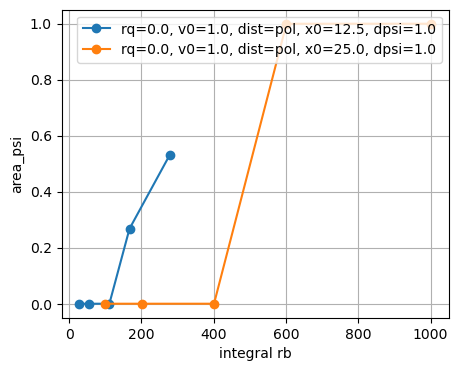

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))

fixed = {
        "rq": 0.0,
        "v0": 1.0,
        "dist": "pol",
        "x0": 12.5, 
        "dpsi": 1.0
        }

plot_vs_fixed(
    df,
    xparam="Nb",
    y="area_psi",
    fixed=fixed, 
    ax=ax
)

fixed["x0"] = 25.0

plot_vs_fixed(
    df,
    xparam="Nb",
    y="area_psi",
    fixed=fixed, 
    ax=ax
)
plt.grid()
# plt.xlim(0, 200)
plt.show()